# NIKHIL TEST: HJR dataset

In [38]:
%load_ext autoreload
%autoreload 2

import torch 
import random
import numpy as np 
from matplotlib import pyplot as plt

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")

from safe_neural_operators.data_collection import load_hjr_solution, \
    get_dynamics_model_given_disturbance_fn, \
    get_disturbance_function_sincos
from safe_neural_operators.hjr_dataset import load_full_training_dataset


sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

from deepreach.dynamics import dynamics 
from deepreach.dynamics import dynamics_hjr
from deepreach.utils.comparisons import GroundTruthHJSolution

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
load_path = "/media/jingpei/DATA/fno_gp_data"
load_index = 0 

loaded_input, loaded_output = load_hjr_solution(
    load_path=load_path,  
    load_index=load_index
)

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  input_tensor = torch.load(input_pat

In [40]:
print(loaded_input.shape)
print(loaded_output.shape)

torch.Size([41, 41, 4])
torch.Size([41, 41, 41, 41])


In [41]:
# Load whole dataset
channel_dim = 1 
input_dataset, output_dataset, grid_states = load_full_training_dataset(root_dir=load_path, 
                                                           num_idxs=100)
og_input_dataset = torch.stack(input_dataset, dim=0)
input_dataset = og_input_dataset[:, :, :, 0].unsqueeze(channel_dim)
output_dataset = torch.stack(output_dataset, dim=0)

print("OG Input dataset shape: ", og_input_dataset.shape)
print("Input dataset shape: ", input_dataset.shape)
print("Output dataset shape: ", output_dataset.shape)

100%|██████████| 100/100 [00:00<00:00, 457.65it/s]


OG Input dataset shape:  torch.Size([100, 41, 41, 4])
Input dataset shape:  torch.Size([100, 1, 41, 41])
Output dataset shape:  torch.Size([100, 41, 41, 41, 41])


In [42]:
# Create sample tuples
grid_resolution = output_dataset.shape[1:]
train_sample_tuple_list = random.sample([[i, j, k] for i in range(grid_resolution[2]) \
                                         for j in range(grid_resolution[3]) \
                                         for k in range(len(input_dataset))], input_dataset.shape[0])
train_sample_tuple_list = np.array(train_sample_tuple_list)
print(train_sample_tuple_list.shape)
print(train_sample_tuple_list[:10, :])

(100, 3)
[[27 26 31]
 [31 26 38]
 [18 25 82]
 [11 31 85]
 [32 39 63]
 [31 13 25]
 [12 33 69]
 [19 35 17]
 [29 31 34]
 [25 18 88]]


In [43]:
# HJR solution to get the Grid States
min_max_magnitude = 0.25 
max_max_magnitude = 0.75 

min_phase_multiplier = 0.05
max_phase_multiplier = 5 

min_phase_shift = 0
max_phase_shift = np.pi / 2

tMin = 0.0 
tMax = 3.0 

num_time_steps = 5

curr_max_magnitude = np.random.uniform(min_max_magnitude, max_max_magnitude)
curr_phase_multiplier = np.random.uniform(min_phase_multiplier, max_phase_multiplier)
curr_phase_shift = np.random.uniform(min_phase_shift, max_phase_shift)

curr_dim = np.random.choice(['x', 'y'])
curr_use_sin = np.random.choice([True, False])

disturbance_function = get_disturbance_function_sincos(
        max_magnitude=curr_max_magnitude, 
        phase_multiplier=curr_phase_multiplier, 
        phase_shift=curr_phase_shift, 
        dim=curr_dim,  # or 'y' depending on the direction you want
        use_sin=curr_use_sin  # or False for cosine
    )

dynamics_model = get_dynamics_model_given_disturbance_fn(
        disturbance_function=disturbance_function, 
        tMin=tMin, 
        tMax=tMax
    )

ground_truth_hj_solution = GroundTruthHJSolution(
    hj_dynamics=dynamics_model, 
    solve=False, 
    num_time_steps=num_time_steps, 
    grid_resolution=grid_resolution, # if None defaults to (51, 51, 51, 51))
)

# Get the grid states
grid_states = ground_truth_hj_solution.grid.states

In [44]:
# get value function for debugging 
ground_truth_hj_solution.solve_hjr()

xvel_slice = 41//2
yvel_slice = 41//2

init_value_function = ground_truth_hj_solution.value_functions[0, :, :, :, :][:, :, xvel_slice, yvel_slice]

time_slice = -1
value_function = ground_truth_hj_solution.value_functions[time_slice, :, :, :, :]
value_function_slice = value_function[:, :, xvel_slice, yvel_slice]

100%|##########|  3.0000/3.0 [00:13<00:00,  4.50s/sim_s]


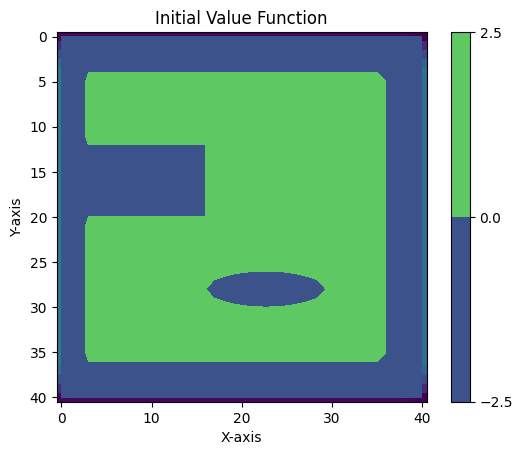

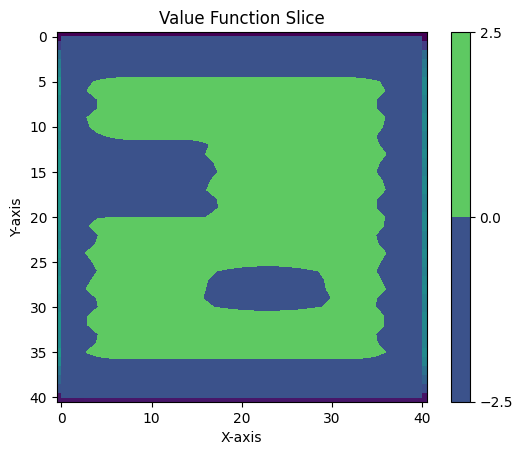

In [45]:
# Plot value function for debugging 
plt.figure()
plt.imshow(np.array(init_value_function))
plt.contourf(np.array(init_value_function), levels=0, cmap='viridis')
plt.colorbar()
plt.title("Initial Value Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


# Plot value function for debugging 
plt.figure()
plt.imshow(np.array(value_function_slice))
plt.contourf(np.array(value_function_slice), levels=0, cmap='viridis')
plt.colorbar()
plt.title("Value Function Slice")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [46]:
# Efficiently create sample dataset from sample tuples
grid_states_sampled = grid_states[0, 0, train_sample_tuple_list[:, 0], train_sample_tuple_list[:, 1]]
grid_states_sampled_xvel = grid_states[0, 0, train_sample_tuple_list[:, 0], 0]
grid_states_sampled_yvel = grid_states[0, 0, 0, train_sample_tuple_list[:, 1]]

grid_states_sampled_xvel = np.array(grid_states_sampled_xvel[:, 2])
grid_states_sampled_yvel = np.array(grid_states_sampled_yvel[:, 3])


print(grid_states_sampled.shape)
print(grid_states_sampled[:, 2])
print("diff xvel: ", grid_states_sampled_xvel - np.array(grid_states_sampled[:, 2]))
print("diff yvel: ", grid_states_sampled_yvel - np.array(grid_states_sampled[:, 3]))

(100, 4)
[ 0.70000005  1.1000001  -0.19999987 -0.90000004  1.2         1.1000001
 -0.79999995 -0.09999996  0.9000001   0.5        -1.4000001   1.2
 -1.5        -1.5         1.9000001   0.70000005 -1.0999999  -0.09999996
  1.8         1.6000001  -0.79999995  0.60000014  1.4000001  -1.5999999
 -0.19999987 -1.0999999   0.79999995  1.9000001  -1.7        -1.9000001
  1.3         0.5         0.79999995 -1.4000001   0.70000005  0.29999995
  1.6000001   0.20000005  1.2         1.5         0.70000005 -0.69999987
  1.2         0.         -2.         -1.3         1.         -1.3
 -1.4000001   1.         -1.2         1.9000001   0.60000014 -1.5999999
 -1.0999999  -1.3         1.2        -0.90000004  1.7        -0.40000004
  0.29999995 -1.5        -1.4000001  -0.59999996  0.20000005 -1.7
 -1.7         1.4000001  -1.         -0.59999996 -0.29999995  1.1000001
  0.9000001   0.9000001   0.70000005 -0.90000004 -1.7        -1.5
  0.9000001  -0.90000004  1.1000001   1.2         0.79999995  1.
  0.400000

In [47]:
# Create full input samples by appending xvel and yvel to the disturbance magnitude [disturbance magnitude, xvel, yvel]
print("type input dataset: ", type(input_dataset))
print("type train_sample_tuple_list: ", type(train_sample_tuple_list))

sampled_input_dataset = input_dataset[train_sample_tuple_list[:, 2], ...]
expand_dims = [-1, grid_resolution[0], grid_resolution[1]]
expand_dims.insert(channel_dim, 1)
print(expand_dims)

appended_sample_xvel = torch.tensor(grid_states_sampled_xvel).view(-1, 1, 1, 1).expand(*expand_dims)
append_sampled_yvel = torch.tensor(grid_states_sampled_yvel).view(-1, 1, 1, 1).expand(*expand_dims)
full_input_samples = torch.cat((sampled_input_dataset, appended_sample_xvel, append_sampled_yvel), dim=channel_dim)

print("Sampled input dataset shape: ", sampled_input_dataset.shape)
print(appended_sample_xvel.shape)
print(append_sampled_yvel.shape)
print("Full input samples shape: ", full_input_samples.shape)

type input dataset:  <class 'torch.Tensor'>
type train_sample_tuple_list:  <class 'numpy.ndarray'>
[-1, 1, 41, 41]
Sampled input dataset shape:  torch.Size([100, 1, 41, 41])
torch.Size([100, 1, 41, 41])
torch.Size([100, 1, 41, 41])
Full input samples shape:  torch.Size([100, 3, 41, 41])


In [48]:
# Create output samples 
print("Output dataset shape: ", output_dataset.shape)
xvel_indices = train_sample_tuple_list[:, 0]
yvel_indices = train_sample_tuple_list[:, 1]
sample_indices = train_sample_tuple_list[:, 2]

output_samples = output_dataset[sample_indices, :, :, xvel_indices, yvel_indices]
print("Output samples shape: ", output_samples.shape)

Output dataset shape:  torch.Size([100, 41, 41, 41, 41])
Output samples shape:  torch.Size([100, 41, 41])


(41, 41)


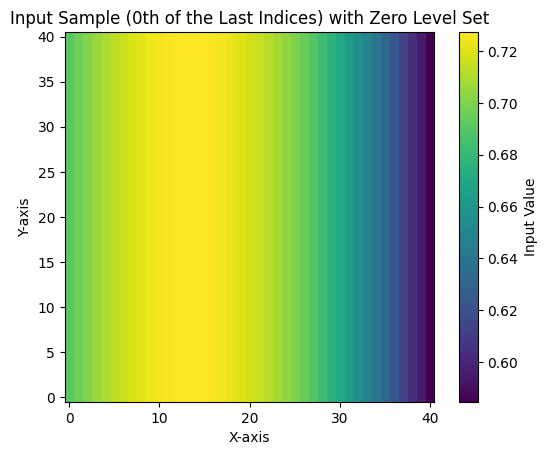

In [53]:
plot_idx = 0

print(sampled_input_dataset[plot_idx, 0, ...].numpy().shape)

plt.figure()
plt.imshow(sampled_input_dataset[plot_idx, 0, ...].numpy(),  origin='lower', cmap='viridis')
plt.colorbar(label='Input Value')
plt.contour(sampled_input_dataset[plot_idx, 0, ...].numpy(), levels=[0], colors='red', )
plt.title("Input Sample (0th of the Last Indices) with Zero Level Set")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


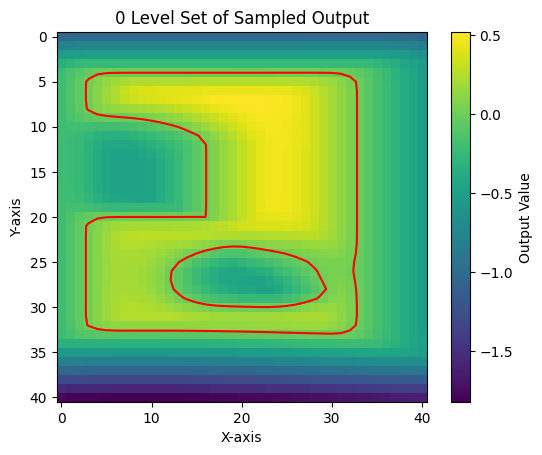

In [54]:
plt.figure()
plt.imshow(output_samples[plot_idx].numpy(), cmap='viridis')
plt.colorbar(label='Output Value')
plt.contour(output_samples[plot_idx].numpy(), levels=[0], colors='red')
plt.title("0 Level Set of Sampled Output")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

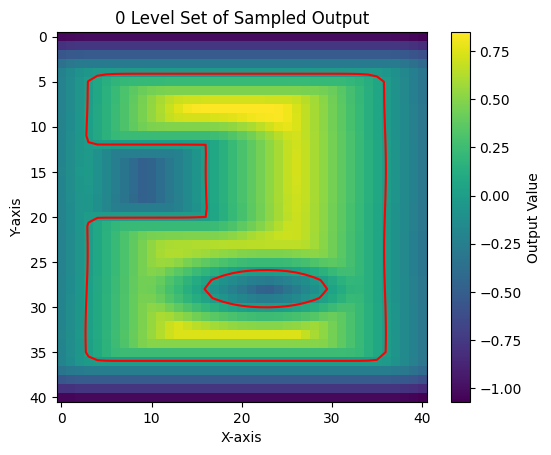

In [55]:
plot_idx = 0 
xvel_slice = 41 // 2
yvel_slice = 41 // 2

plt.figure()
plt.imshow(output_dataset[plot_idx, :, :, xvel_slice, yvel_slice].numpy(), cmap='viridis')
plt.colorbar(label='Output Value')
plt.contour(output_dataset[plot_idx, :, :, xvel_slice, yvel_slice].numpy(), levels=[0], colors='red')
plt.title("0 Level Set of Sampled Output")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()